# Project 03 — Energy Efficiency Classification

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git config --global user.email "spoorthyece@gmail.com"
!git config --global user.name "Spoorthy2001"

In [3]:
import kagglehub
path = kagglehub.dataset_download("taruneshburman/energy-consumption-efficiency-dataset")

100%|██████████| 44.9k/44.9k [00:00<00:00, 34.5MB/s]

Extracting files...


## Importing Data

In [4]:
import os
import pandas as pd

print(os.listdir(path))

df = pd.read_csv(path + '/Energy_Consumption_Efficiency.csv')
df.head()

['Energy_Consumption_Efficiency.csv']


,Energy_Consumed,Production_Output,Renewable_Energy_Usage,Equipment_Age,Maintenance_Frequency,Operator_Training,Downtime_Hours,Automation_Level,Industry_Type,Region,Efficiency_Class
0,1891.153010,17.233715,27.784401,4,2,Basic,18.640699,Medium,Manufacturing,East,Low
1,3132.728859,97.800943,78.890762,18,1,Advanced,34.170472,Low,Manufacturing,North,High
2,4527.735814,89.915841,28.768649,12,3,Basic,6.010864,Medium,Technology,South,Low
3,2380.619221,12.008692,18.205539,15,6,Basic,30.807997,Low,Manufacturing,East,High
4,2197.177334,30.269299,15.074026,8,1,Intermediate,16.196838,Medium,Technology,East,Low


## Exploratory Data Analysis
- Target distribution
- Feature distributions
- Correlation matrix
- Categorical features
- Feature vs Target relationships

## 1. Target variable distribution analysis

- Balanced -  all the classificatino labels have balanced outcomes

In [5]:
# df.info()
# df.shape
# df.isnull().sum()
df['Efficiency_Class'].value_counts()

,count
Efficiency_Class,
Low,349
Medium,346
High,305


In [6]:
df.describe()

,Energy_Consumed,Production_Output,Renewable_Energy_Usage,Equipment_Age,Maintenance_Frequency,Downtime_Hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3057.215479,55.212837,45.121239,9.906000,5.892000,19.738371
std,1146.938581,26.538476,20.092294,5.500675,3.291986,11.465611
min,1001.740925,10.134204,10.078715,1.000000,1.000000,0.190654
25%,2127.439517,31.139289,28.161000,5.000000,3.000000,9.903890
50%,3026.915431,55.233483,45.167813,10.000000,6.000000,19.524635
75%,4110.919605,79.053641,61.897900,15.000000,9.000000,29.898896
max,4995.994077,99.986755,79.963448,19.000000,11.000000,39.979555


/tmp/ipykernel_1990/3514546802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=df['Efficiency_Class'], order=['Low', 'Medium', 'High'], palette=['tomato', 'orange', 'steelblue'])


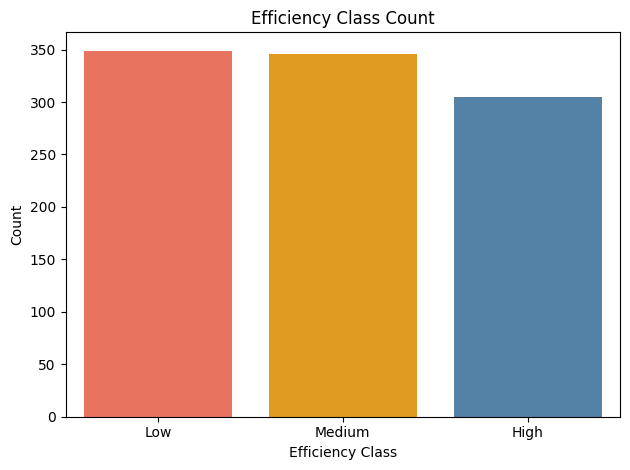

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x=df['Efficiency_Class'], order=['Low', 'Medium', 'High'], palette=['tomato', 'orange', 'steelblue'])
plt.title("Efficiency Class Count")
plt.xlabel("Efficiency Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2. Feature distribution analysis

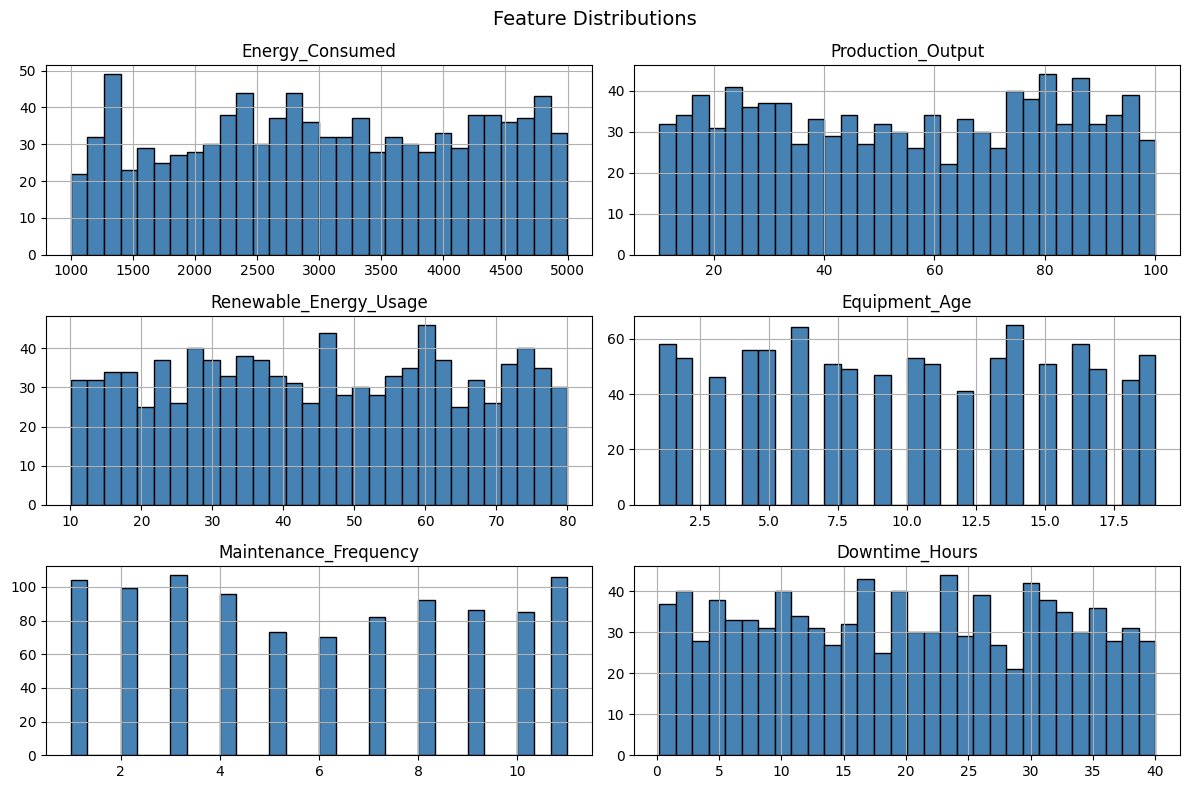

In [8]:
df.hist(figsize=(12, 8), bins=30, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
print(df['Maintenance_Frequency'].unique())
print(df['Maintenance_Frequency'].value_counts())

[ 2  1  3  6  5  8  4 11 10  7  9]
Maintenance_Frequency
3     107
11    106
1     104
2      99
4      96
8      92
9      86
10     85
7      82
5      73
6      70
Name: count, dtype: int64


In [10]:
print(df.groupby('Maintenance_Frequency')['Efficiency_Class'].value_counts())

Maintenance_Frequency  Efficiency_Class
1                      Medium              39
                       Low                 34
                       High                31
2                      Low                 36
                       High                34
                       Medium              29
3                      Low                 44
                       Medium              35
                       High                28
4                      Low                 40
                       High                28
                       Medium              28
5                      Medium              29
                       Low                 26
                       High                18
6                      Low                 26
                       High                25
                       Medium              19
7                      Medium              32
                       High                26
                       Low              

## 3. Correlation Matrix

In [11]:
df.corr(numeric_only=True)

,Energy_Consumed,Production_Output,Renewable_Energy_Usage,Equipment_Age,Maintenance_Frequency,Downtime_Hours
Energy_Consumed,1.000000,0.031854,-0.016781,-0.022913,-0.016837,0.025202
Production_Output,0.031854,1.000000,-0.026147,-0.067171,-0.014007,0.031760
Renewable_Energy_Usage,-0.016781,-0.026147,1.000000,-0.066137,0.027089,-0.011893
Equipment_Age,-0.022913,-0.067171,-0.066137,1.000000,-0.039312,-0.020862
Maintenance_Frequency,-0.016837,-0.014007,0.027089,-0.039312,1.000000,-0.045462
Downtime_Hours,0.025202,0.031760,-0.011893,-0.020862,-0.045462,1.000000


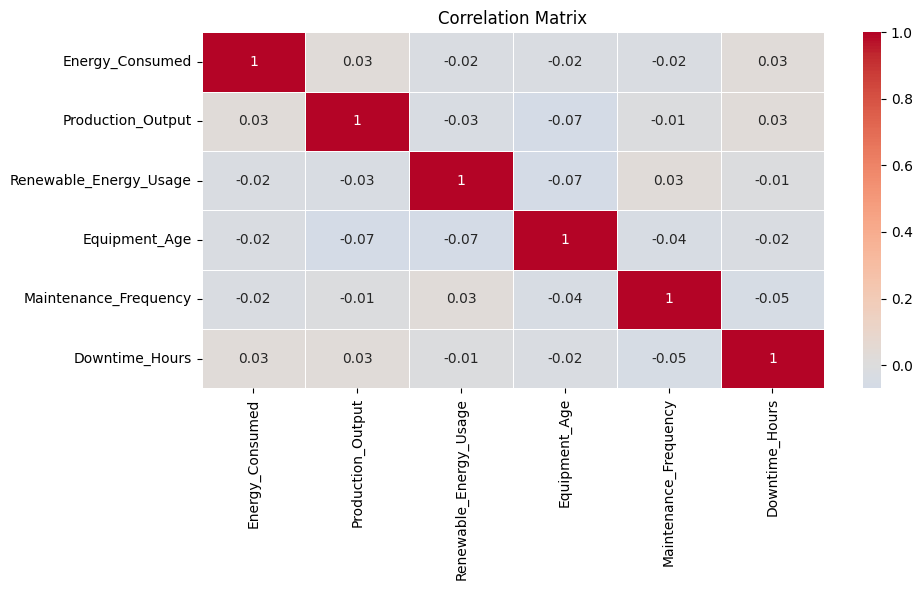

In [12]:
continuous = ['Energy_Consumed', 'Production_Output', 'Renewable_Energy_Usage', 'Equipment_Age', 'Maintenance_Frequency', 'Downtime_Hours']
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True).round(2), annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

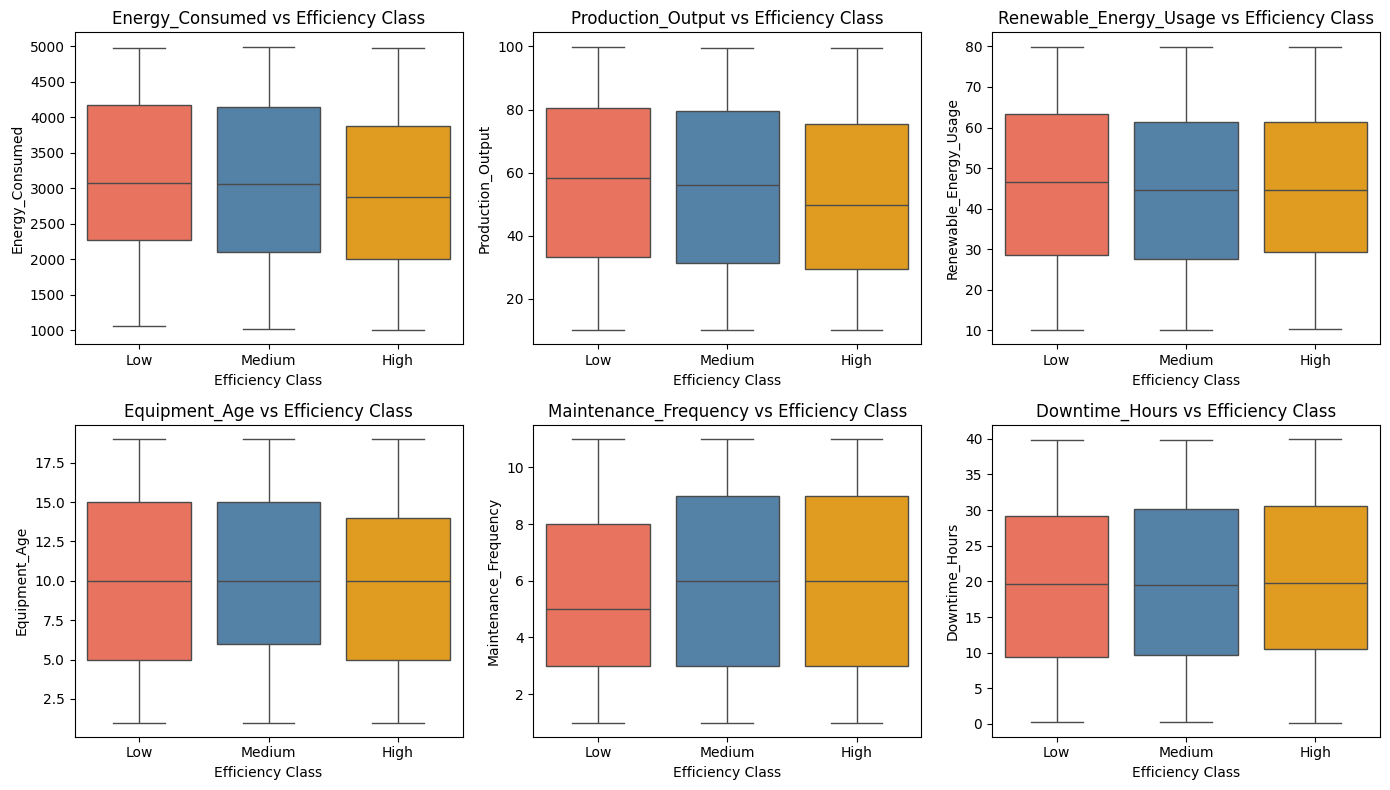

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

continuous = ['Energy_Consumed', 'Production_Output', 'Renewable_Energy_Usage', 'Equipment_Age', 'Maintenance_Frequency', 'Downtime_Hours']

for i, feature in enumerate(continuous):
    sns.boxplot(data=df, x='Efficiency_Class', y=feature, legend = False, hue='Efficiency_Class', order=['Low', 'Medium', 'High'], palette=['tomato', 'orange', 'steelblue'], ax=axes[i])
    axes[i].set_title(f"{feature} vs Efficiency Class")
    axes[i].set_xlabel("Efficiency Class")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()


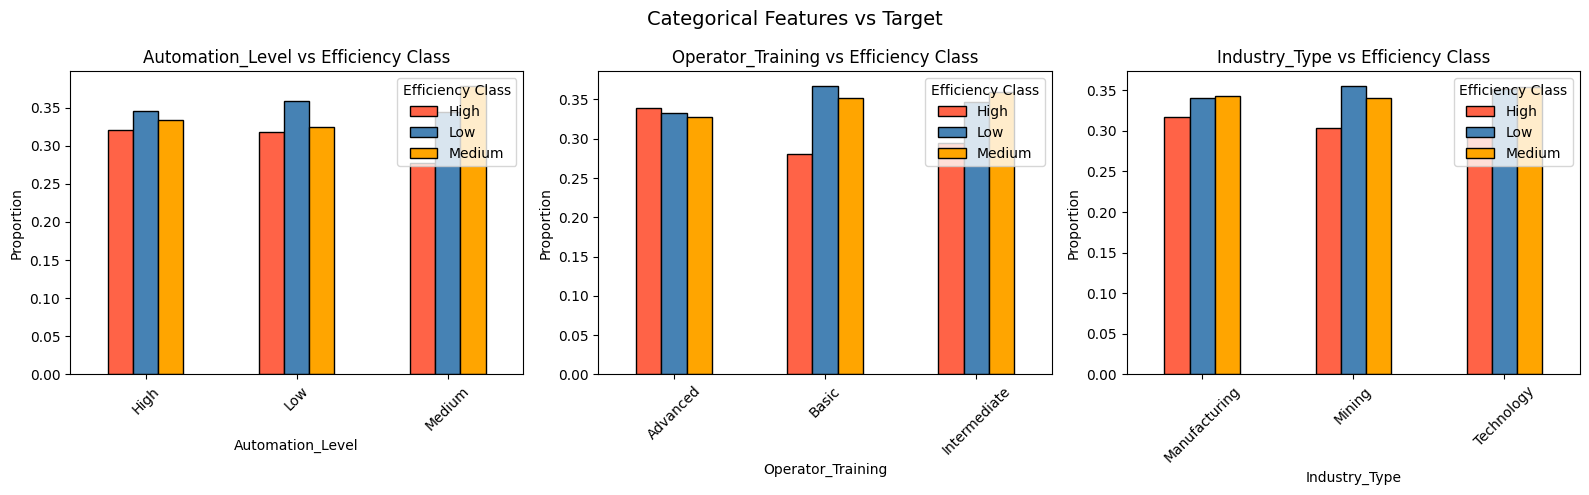

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

categoricals = ['Automation_Level', 'Operator_Training', 'Industry_Type']

for i, feature in enumerate(categoricals):
    ct = pd.crosstab(df[feature], df['Efficiency_Class'], normalize='index')
    ct.plot(kind='bar', ax=axes[i],
            color=['tomato', 'steelblue', 'orange'],
            edgecolor='black')
    axes[i].set_title(f"{feature} vs Efficiency Class")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Efficiency Class')

plt.suptitle("Categorical Features vs Target", fontsize=14)
plt.tight_layout()
plt.show()

## Feature Encoding

In [29]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding

le = LabelEncoder()

df_encoded = df.copy()

df_encoded['Operator_Training'] = le.fit_transform(df_encoded['Operator_Training'])
df_encoded['Automation_Level'] = le.fit_transform(df_encoded['Automation_Level'])

#One hot encoding

df_encoded = pd.get_dummies(df_encoded, columns=['Industry_Type', 'Region'], drop_first=True)

#Target variable Encoding

df['Efficiency_Class'] = le.fit_transform(df_encoded['Efficiency_Class'])

# print(df_encoded.shape)
# print(df_encoded.columns.tolist())
# df.head()
print(df_encoded['Efficiency_Class'])

0      1
1      0
2      1
3      0
4      1
      ..
995    0
996    1
997    1
998    1
999    1
Name: Efficiency_Class, Length: 1000, dtype: int64


## Model training

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_encoded.drop('Efficiency_Class', axis=1)
y = df_encoded['Efficiency_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_1 = LogisticRegression(max_iter=1000, random_state=42)
model_1.fit(X_train_scaled, y_train)

y_pred_1 = model_1.predict(X_test_scaled)


# print("y_train :: ", y_train)
print("--- Model 1 --- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_1) :.4f}")
print(classification_report(y_test, y_pred_1))

y_train ::  29     2
535    2
695    0
557    1
836    2
      ..
106    2
270    2
860    2
435    0
102    2
Name: Efficiency_Class, Length: 800, dtype: int64
--- Model 1 --- Logistic Regression ---
Accuracy: 0.3700
              precision    recall  f1-score   support

           0       0.44      0.21      0.28        73
           1       0.35      0.63      0.45        57
           2       0.37      0.33      0.35        70

    accuracy                           0.37       200
   macro avg       0.39      0.39      0.36       200
weighted avg       0.39      0.37      0.35       200



## Model 2 - Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(n_estimators=500, random_state=42)
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

# print("y_train :: ", y_train)
print("--- Model 2 --- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_2) :.4f}")
print(classification_report(y_test, y_pred_2,
      target_names=['High', 'Low', 'Medium']))

y_train ::  29     2
535    2
695    0
557    1
836    2
      ..
106    2
270    2
860    2
435    0
102    2
Name: Efficiency_Class, Length: 800, dtype: int64
--- Model 2 --- Random Forest ---
Accuracy: 0.3800
              precision    recall  f1-score   support

        High       0.43      0.22      0.29        73
         Low       0.35      0.56      0.43        57
      Medium       0.39      0.40      0.40        70

    accuracy                           0.38       200
   macro avg       0.39      0.39      0.37       200
weighted avg       0.39      0.38      0.37       200



In [32]:
y_train

,Efficiency_Class
29,2
535,2
695,0
557,1
836,2
...,...
106,2
270,2
860,2
435,0


In [34]:
from xgboost import XGBClassifier

model_3 = XGBClassifier(n_estimators=500,
                        max_depth=4,
                         random_state=42,
                         eval_metric='mlogloss')
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)

print("--- Model 3 --- XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_3):.4f}")
print(classification_report(y_test, y_pred_3,
      target_names=['High', 'Low', 'Medium']))

--- Model 3 --- XGBoost ---
Accuracy: 0.3550
              precision    recall  f1-score   support

        High       0.38      0.27      0.32        73
         Low       0.30      0.35      0.33        57
      Medium       0.38      0.44      0.41        70

    accuracy                           0.35       200
   macro avg       0.35      0.36      0.35       200
weighted avg       0.36      0.35      0.35       200



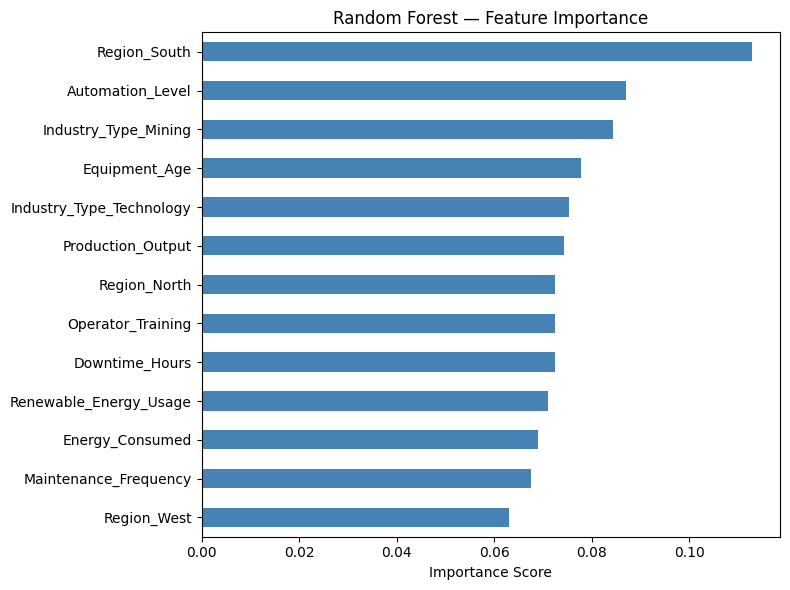

In [36]:
# If target was randomly assigned,
# feature importance should be near equal for all features

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model_3.feature_importances_,
                       index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6),
                               color='steelblue')
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### Conclusion - Project 03 — Energy Efficiency Classification

---



**Key Finding:**
All 3 models stuck at 35-38% accuracy.
Feature importance near equal across all features.
EDA showed no class separation in box plots.

**Conclusion:**
Dataset has weak feature-target relationship.
Likely synthetic with randomly assigned labels.
Algorithm choice doesn't matter when signal is absent.

**The Lesson:**
Recognise bad data early.
Don't chase accuracy with better algorithms
when the data itself is the problem.